# Circular Waveguide Analysis

This notebook demonstrates a complete circular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
import matplotlib.pyplot as plt
from analytical.circular_waveguide import CWGAnalytical
%matplotlib widget
plt.rcParams['figure.dpi'] = 100

# Create New EM Project

In [2]:
from core.em_project import EMProject

proj = EMProject("CircularWG", 
base_dir=r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations")

Creating new project 'CircularWG' at C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CircularWG


# Define Geometry

Create a circular waveguide with specified dimensions and mesh parameters.

In [3]:
# Waveguide parameters
radius = 150e-3  # Width: 100 mm
L = 300e-3  # Length: 200 mm
maxh = 0.04  # Mesh size

proj.create_primitive('cwg', radius=radius, length=L, maxh=maxh)
# Create waveguide geometry
# cwg = CircularWaveguide(radius, L, maxh=maxh)
# # save step file
# cwg.save_step(r"./circular_waveguide.step")

# print(f"Dimensions: radius={radius * 1e3:.0f}mm, L={cwg.length * 1e3:.0f}mm, L={L * 1e3:.0f}mm")
# # print(f"Cutoff frequency (TE10): {cwg.cutoff_frequency_TE11 / 1e9:.3f} GHz")
# print(f"Mesh DOFs: ~{cwg.mesh.nv} vertices")

proj.geo.show()
proj.geo.print_info()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …


CircularWaveguide Geometry Information
Geometry type:          CircularWaveguide
Compute method:         numeric
Supports analytical:    True
Boundary condition:     wall

Component Tag:
  Full:                 CircularWaveguide:5ea1e459
  Geometry hash:        5ea1e459ab4a6836...

Cache status:           NOT CACHED

Mesh generated:         True
  Vertices:             391
  Elements:             1,354
  Ports:                ['port2', 'port1']


## Analytical Solution

Compute the analytical Z-parameters for comparison with numerical results.

In [4]:
# Analytical
analytical = CWGAnalytical(radius=radius, length=L)

# FOM solve
%time result = proj.fds.solve(0.1, 1.5, 30, order=3, nportmodes=3, store_snapshots=True, solver_type='iterative')


Structure Topology
Type: Single structure
Domains (1): ['vacuum']
Total Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port2: circular (fit error: 0.0000)
	    R=0.150001
	  port1: circular (fit error: 0.0000)
	    R=0.150001
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
	port2 mode 0: TE_11 (cos), kc=12.2745, σ=-1
	port2 mode 1: TE_11 (sin), kc=12.2745, σ=-1
	port2 mode 2: TM_01, kc=16.0321, σ=-1


	port1 mode 0: TE_11 (cos), kc=12.2745, σ=+1
	port1 mode 1: TE_11 (sin), kc=12.2745, σ=+1
	port1 mode 2: TM_01, kc=16.0321, σ=+1


	------------------------------------------------------------
	Total modes: 6

--- Assembling Per-Domain Matrices ---

Domai

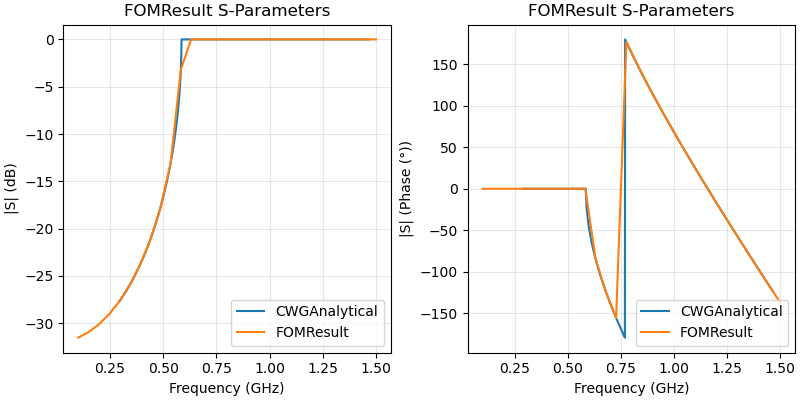

In [5]:
which = ['1(1)2(1)']
fig, axs = plt.subplot_mosaic([[1, 2]], figsize=(8, 4), layout='constrained')
# magnitude
analytical.plot_s(which, ax=axs[1])
proj.fds.fom.plot_s(which, ax=axs[1])
# phase
fig, ax = analytical.plot_s(which, ax=axs[2], plot_type='phase')
fig, ax = proj.fds.fom.plot_s(which, ax=axs[2], plot_type='phase')

In [6]:
proj.fds.port_solver.print_info()


Port Eigenmode Solver Information
Mode source:          ANALYTIC
Polynomial order:     3
Dirichlet BC label:   wall
Polarization angle:   0.0°
Ensure inward power:  True
Global up direction:  [0. 1. 0.]
Propagation axis:     [0. 0. 1.]
Geometry tolerance:   0.0500

Number of detected/solved ports: 2
Total number of modes:           6

----------------------------------------------------------------------
Per-port summary:
----------------------------------------------------------------------
  port1:
    Geometry:       circular
    Fit error:      0.0000
    Radius:         R = 0.150001
    Area:           7.068642e-02
    Orientation σ:  +1
    Normal:         [ 0.  0. -1.]
    Modes found:    3
    Lowest fc:      0.5857 GHz
    Highest fc:     0.7649 GHz
    Modes (example):
      TE_11 (TE, 0.586 GHz (degen=2) pol=0°)
      TE_11 (TE, 0.586 GHz (degen=2) pol=90°)
      TM_01 (TM, 0.765 GHz pol=0°)

  port2:
    Geometry:       circular
    Fit error:      0.0000
    Radius:      

In [7]:
proj.fds.plot_port_mode('port1', 1)


Port Mode: port1 [external (input)], Mode 1
Cutoff frequency: 0.5857 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [8]:
proj.fds.plot_port_mode('port2', 0)


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 0.5857 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [9]:
proj.fds.plot_field(15)


Field visualization at f = 0.8241 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (None)


C:\Users\Soske\Documents\git_projects\cavsim3d\solvers\frequency_domain.py:3507: ComplexWarning: Casting complex values to real discards the imaginary part
  E_gf.vec.FV().NumPy()[:] = snapshots[:, snapshot_idx]


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [10]:
proj.fds.fom.get_resonant_frequencies()

array([2.92013541e+02, 3.84948137e+02, 4.32001753e+02, 5.38142191e+02,
       6.11115191e+02, 6.50018404e+02, 6.81472251e+02, 7.32689344e+02,
       7.61150225e+02, 8.09550094e+02, 8.17782640e+02, 8.32272193e+02,
       8.92185760e+02, 1.09050124e+03, 5.85660563e+08, 5.85660665e+08,
       7.69839520e+08, 7.69839737e+08, 9.13675505e+08, 9.71522270e+08,
       9.71522454e+08, 1.09248066e+09, 1.09248192e+09, 1.15828696e+09,
       1.15828773e+09, 1.21883702e+09, 1.25848658e+09, 1.31728053e+09,
       1.31728430e+09, 1.31728705e+09, 1.33637431e+09, 1.33637595e+09,
       1.39374845e+09, 1.39374996e+09, 1.42673381e+09])

In [11]:
# get reduced order model
proj.fds.fom.reduce()


Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 37428
  Snapshots: 180
  Reduced DOFs: 35
  Compression: 99.9%
  Singular value decay: 2.48e+06 → 1.04e+00

------------------------------------------------------------
Total: 37428 → 35 DOFs
Overall compression: 99.9%
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CircularWG
FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\CircularWG\fds


In [12]:
proj.fds.fom.rom.get_resonant_frequencies()

array([1.49488040e+03, 6.72623706e+03, 1.66151960e+08, 2.74954287e+08,
       3.96243593e+08, 3.99834950e+08, 5.85660563e+08, 5.85660665e+08,
       7.69839520e+08, 7.69839737e+08, 9.13675505e+08, 1.15828696e+09,
       1.15828773e+09, 1.25848658e+09, 1.60937262e+09, 1.60937761e+09,
       1.68294711e+09, 2.08319555e+09, 2.08321860e+09, 2.14075286e+09,
       2.56148376e+09, 2.56689872e+09, 2.61204220e+09, 3.20811624e+09,
       3.20981240e+09, 3.26475890e+09, 3.52731140e+09, 3.75081677e+09,
       3.87246196e+09, 8.20000909e+09, 8.21419236e+09, 8.38233875e+09,
       8.61186269e+09, 9.37481256e+09, 9.91925134e+09])

In [13]:
analytical.get_resonant_frequencies()

array([7.69840031e+08, 1.15828162e+09, 1.60931271e+09, 2.08265862e+09,
       2.56599978e+09, 3.05459510e+09, 3.54627355e+09, 4.03990957e+09,
       4.53486394e+09, 5.03074757e+09])

(1.0, 2.0)

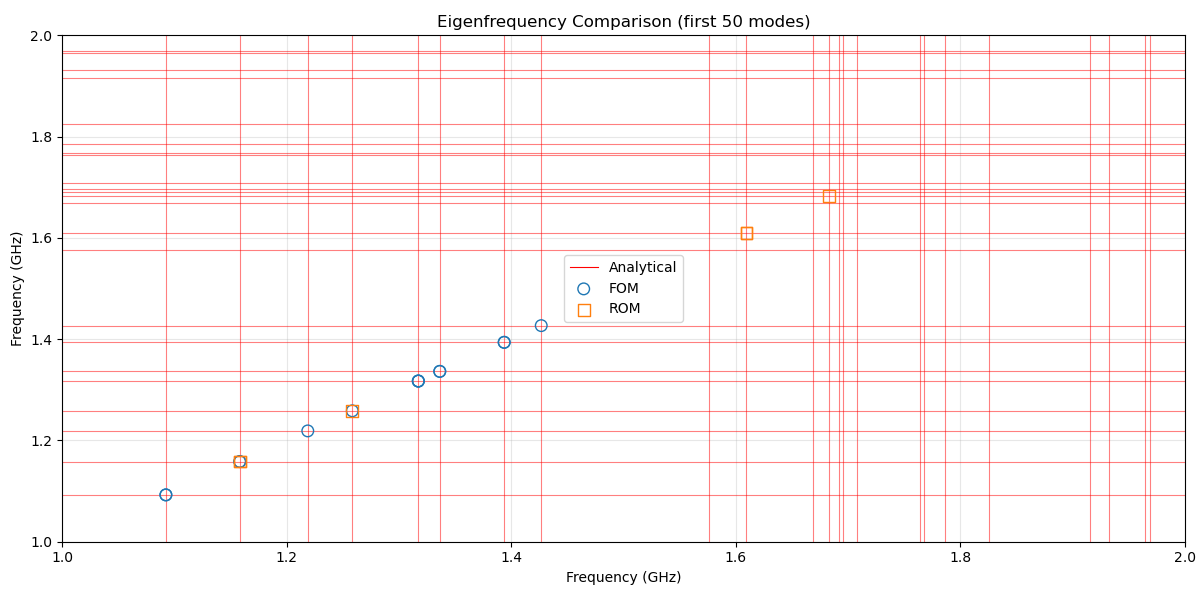

In [17]:
from utils.visualization import *
fig, ax = plot_eigenfrequencies([proj.fds.fom, proj.fds.fom.rom], analytical=analytical,
                      labels=['FOM', 'ROM'], n_modes=50)
ax.set_ylim(1, 2)
ax.set_xlim(1, 2)